# Notebook 01: **Data Loading and Sanity Checks for SemanticKITTI**

---

## 1. Purpose of This Notebook

This notebook is the entry gate to the project pipeline.

Before doing reflectivity-aware analysis, multi-frame motion visualization, or semantic interpretation, we first need to confirm that the dataset can be loaded correctly and that the raw LiDAR signals behave as expected. This notebook is therefore designed as a **feasibility and validation notebook**, not as a full analysis notebook.

The main purpose here is to:

- load one SemanticKITTI sequence correctly.
- inspect the raw LiDAR frame format.
- inspect the corresponding label format.
- verify that points and labels are aligned.
- compute a few basic geometric and signal statistics.
- prepare a clean foundation for the later notebooks.

This notebook is intentionally simple. It is meant to prove that the data pipeline works and that the project starts from a reliable base.

## 2. Why This Notebook Matters

The broader project studies whether **reflectivity-like information derived from LiDAR intensity** can be useful for robotic scene understanding. However, the project plan is clear that the early phase should focus on feasibility first:

- make the pipeline work.
- produce clean single-frame results.
- produce limited multi-frame results over roughly 30 to 60 frames.
- attach semantics only in a limited way during the preliminary phase.

That means this first notebook should not try to do everything at once.

Its job is to answer a few basic but critical questions:

- Can we read SemanticKITTI frames correctly?
- What is the shape of the point cloud data?
- What is stored in each point?
- Do the labels line up with the points?
- What do the intensity and range distributions look like?
- Are the loaded values numerically sensible?

If this notebook is clean, then every later notebook stands on solid ground.

## 3. Conceptual Background

A LiDAR sensor measures a scene as a collection of points.  
Each point usually contains:

- spatial position
- signal return strength

In SemanticKITTI, each LiDAR point is represented by four values:

- `x`
- `y`
- `z`
- `intensity`

So each point can be viewed as:

$$
p = (x, y, z, I)
$$

where:

- $x, y, z$ are the 3D coordinates of the point.
- $I$ is the recorded LiDAR intensity.

This notebook focuses on understanding and validating that raw representation.

We are **not yet claiming recovered physical reflectivity** here.  
That comes later, and even then, the project uses a simplified **pseudo-reflectivity** approximation rather than a fully calibrated reflectivity recovery pipeline.

So in this notebook, the goal is humble and important:

> load the dots, trust the dots, and verify the dots are not lying.

## 4. Mathematical Model Used in This Notebook

There is not a lot of heavy mathematics in Notebook 1, and that is perfectly fine.

The main mathematical objects used here are:

### 4.1 Point Representation

Each LiDAR point is:

$$
p = (x, y, z, I)
$$

This is the raw signal representation used in the dataset.

### 4.2 Range Computation

A useful derived quantity is the **range**, which is the Euclidean distance of a point from the LiDAR sensor:

$$
R = \sqrt{x^2 + y^2 + z^2}
$$

This quantity is important even in the first notebook because:

- it helps us understand scene geometry.
- it gives a first sanity check on sensor reach.
- it prepares for later reflectivity-aware analysis.

### 4.3 Signal Interpretation Preview

Later notebooks will use the simplified interpretation that raw intensity is influenced by both intrinsic surface behavior and measurement geometry. A practical signal relationship is commonly expressed as:

$$
I \propto \frac{\rho \cos(\alpha)}{R^2}
$$

where:

- $\rho$ is surface reflectivity.
- $\alpha$ is incidence angle.
- $R$ is range.

This matters because raw intensity is **not purely an intrinsic material property**.

However, this notebook does **not** attempt to solve that calibration problem.  
It only prepares the data needed for that later stage.

## 5. What This Notebook Will Actually Do

This notebook will proceed in a strict step-by-step protocol.

### Step A: Define the dataset path
We first locate the SemanticKITTI subset and identify the sequence folder to be used.

### Step B: Verify the directory layout
We check that the required files and folders exist, such as:

- `velodyne/`
- `labels/`
- `calib.txt`
- `poses.txt`
- `times.txt`

This confirms that the sequence structure matches expectations.

### Step C: Load one LiDAR frame
We read one `.bin` file and reshape it into a point cloud of size:

$$
N \times 4
$$

where $N$ is the number of points in the selected frame.

### Step D: Load one label frame
We read the matching `.label` file and verify that the number of labels equals the number of points.

### Step E: Separate raw channels
From the point cloud, we isolate:

- coordinates: $x, y, z$
- intensity: $I$

From the labels, we extract semantic information for later inspection.

### Step F: Compute basic derived quantities
We compute range for each point:

$$
R_i = \sqrt{x_i^2 + y_i^2 + z_i^2}
$$

This gives us a geometric descriptor for the frame.

### Step G: Perform sanity checks
We print and inspect:

- point-cloud shape.
- label shape.
- data types.
- sample rows.
- minimum and maximum values.
- mean and standard deviation of intensity.
- mean and standard deviation of range.

### Step H: Produce basic visual summaries
We create simple graphs that help us visually validate the data.

## 6. Metrics Used in This Notebook

This notebook is not yet using model evaluation metrics like IoU or mIoU.  
Those belong to later phases if an actual segmentation model is built.

Instead, the metrics here are **sanity metrics** and **descriptive statistics**.

### 6.1 Structural Metrics

These confirm the dataset is loaded correctly:

- number of points in the frame.
- number of labels in the frame.
- whether point count equals label count.
- frame dimensionality.
- label dimensionality.
- data types of arrays.

### 6.2 Signal Statistics

These summarize the raw LiDAR signal:

For intensity:

- minimum intensity.
- maximum intensity.
- mean intensity.
- standard deviation of intensity.

For range:

- minimum range.
- maximum range.
- mean range.
- standard deviation of range.

### 6.3 Class Snapshot Statistics

For one selected frame:

- unique semantic classes present.
- point count per class.
- proportion of each class in that frame.

This is not yet a full semantic study.  
It is only a frame-level snapshot to confirm that labels are meaningful and aligned.

## 7. Graphs and Visual Outputs Expected in This Notebook

This notebook should end with a few simple but useful visual checks.

### 7.1 Intensity Histogram

A histogram of raw intensity values in one frame.

Why it matters:

- shows the spread of LiDAR return strengths.
- helps detect strange scaling or corrupted values.
- gives a baseline for later reflectivity-style analysis.

### 7.2 Range Histogram
A histogram of point ranges in one frame.

Why it matters:

- shows how points are distributed by sensor distance.
- helps verify that the scene geometry is sensible.
- provides context for later range-compensated analysis.

### 7.3 Bird’s-Eye View Scatter Plot
A top-view scatter of points using $x$ and $y$, optionally colored by intensity.

Why it matters:

- gives an immediate visual sanity check of scene structure.
- confirms the frame resembles a driving environment rather than numeric soup.
- helps verify that the coordinate system is being read correctly.

### 7.4 Optional Class Count Bar Plot

A bar chart showing the number of points in each semantic class for one frame.

Why it matters:

- confirms semantic labels are present and nontrivial.
- gives a first glimpse of scene composition.
- prepares for later semantic interpretation notebooks.

## 8. What This Notebook Does **Not** Attempt

To keep scope disciplined, this notebook deliberately avoids doing too much.

It does **not** yet attempt:

- full reflectivity calibration.
- pseudo-reflectivity analysis in depth.
- multi-frame motion analysis.
- long temporal consistency study.
- semantic segmentation training.
- IoU or mIoU evaluation.
- deployment or real-time system design.

That restraint is important.

The project plan explicitly recommends that the preliminary stage should prove feasibility without consuming the whole project. This first notebook is therefore about correctness, clarity, and readiness, not about squeezing every possible result into one file.

## 9. Expected Outcome by the End of This Notebook

By the end of this notebook, we expect to have:

1. a confirmed working SemanticKITTI loading pipeline.  
2. one LiDAR frame successfully loaded as a numeric point cloud.  
3. one matching label frame successfully loaded.  
4. verified alignment between points and labels.  
5. basic descriptive statistics for intensity and range.  
6. at least a few visual sanity plots.  
7. confidence that later notebooks can safely build on this data.

In practical terms, the notebook should leave us with a clean answer to this question:

> Can we trust the raw data pipeline enough to begin reflectivity-aware analysis next?

If the answer is yes, then Notebook 2 can move into single-frame reflectivity-style analysis, and later notebooks can scale to short temporal windows such as 30 to 60 frames.

## 10. Final Note

This notebook is intentionally the quiet one.

No fireworks yet.  
No grand claims yet.  
No segmentation hero arc yet.

Just disciplined loading, verification, and first-contact understanding of the data.

That is exactly what a good first notebook should do.

---

## Step 1: Locate the dataset and verify the sequence structure

In this step, we define the dataset path and check whether the expected SemanticKITTI sequence files and folders are present.

We are not loading any point clouds yet.  
The goal here is only to confirm that the notebook is looking at the correct location and that the basic directory structure is valid before moving forward.

In [2]:
from pathlib import Path

# Assume the notebook is being run from the notebooks/ directory
DATASET_ROOT = Path("../data/semantickitti_subset/dataset/sequences/00")

expected_items = [
    "velodyne",
    "labels",
    "calib.txt",
    "poses.txt",
    "times.txt",
]

print("Dataset root:", DATASET_ROOT.resolve())
print("Exists:", DATASET_ROOT.exists())
print()

for item in expected_items:
    item_path = DATASET_ROOT / item
    print(f"{item:10} -> exists: {item_path.exists()} | path: {item_path}")

print()
if DATASET_ROOT.exists():
    print("Contents of sequence folder:")
    for p in sorted(DATASET_ROOT.iterdir()):
        print(" -", p.name)
else:
    print("Dataset root not found. Check the DATASET_ROOT path.")

Dataset root: /home/twilightpriest/GitHub/reflect-aug-seg/data/semantickitti_subset/dataset/sequences/00
Exists: True

velodyne   -> exists: True | path: ../data/semantickitti_subset/dataset/sequences/00/velodyne
labels     -> exists: True | path: ../data/semantickitti_subset/dataset/sequences/00/labels
calib.txt  -> exists: True | path: ../data/semantickitti_subset/dataset/sequences/00/calib.txt
poses.txt  -> exists: True | path: ../data/semantickitti_subset/dataset/sequences/00/poses.txt
times.txt  -> exists: True | path: ../data/semantickitti_subset/dataset/sequences/00/times.txt

Contents of sequence folder:
 - calib.txt
 - labels
 - poses.txt
 - times.txt
 - velodyne


## Step 2: List available frames and confirm file counts

In this step, we inspect the `velodyne` and `labels` folders to confirm that frame files are present and that both folders contain matching counts.

This gives us a quick structural sanity check before loading the first frame.

In [3]:
velodyne_dir = DATASET_ROOT / "velodyne"
labels_dir = DATASET_ROOT / "labels"

velodyne_files = sorted(velodyne_dir.glob("*.bin"))
label_files = sorted(labels_dir.glob("*.label"))

print("Number of .bin frames   :", len(velodyne_files))
print("Number of .label frames :", len(label_files))
print()

if velodyne_files:
    print("First 5 velodyne frames:")
    for f in velodyne_files[:5]:
        print(" -", f.name)

print()

if label_files:
    print("First 5 label frames:")
    for f in label_files[:5]:
        print(" -", f.name)

print()
if velodyne_files and label_files:
    velodyne_stems = [f.stem for f in velodyne_files]
    label_stems = [f.stem for f in label_files]

    print("Counts match:", len(velodyne_files) == len(label_files))
    print("Frame IDs match:", velodyne_stems == label_stems)

    if velodyne_stems == label_stems:
        print("Sample frame ID:", velodyne_stems[0])

Number of .bin frames   : 4541
Number of .label frames : 4541

First 5 velodyne frames:
 - 000000.bin
 - 000001.bin
 - 000002.bin
 - 000003.bin
 - 000004.bin

First 5 label frames:
 - 000000.label
 - 000001.label
 - 000002.label
 - 000003.label
 - 000004.label

Counts match: True
Frame IDs match: True
Sample frame ID: 000000


## Step 3: Load the first LiDAR frame

In this step, we load the first `.bin` file from the `velodyne` folder.

Each SemanticKITTI LiDAR frame stores raw point-cloud data as float32 values arranged as four channels per point:

- `x`
- `y`
- `z`
- `intensity`

The goal here is to load the first frame, reshape it into an `N x 4` array, and inspect its basic structure.

In [4]:
import numpy as np

frame_id = velodyne_files[0].stem
bin_path = velodyne_dir / f"{frame_id}.bin"

points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)

print("Frame ID:", frame_id)
print("File path:", bin_path)
print("Points array shape:", points.shape)
print("Data type:", points.dtype)
print()

print("First 5 points:")
print(points[:5])

Frame ID: 000000
File path: ../data/semantickitti_subset/dataset/sequences/00/velodyne/000000.bin
Points array shape: (124668, 4)
Data type: float32

First 5 points:
[[5.2897942e+01 2.2989739e-02 1.9979945e+00 7.9999998e-02]
 [5.3750526e+01 1.9291429e-01 2.0269539e+00 0.0000000e+00]
 [5.3803116e+01 3.6183926e-01 2.0289137e+00 0.0000000e+00]
 [7.2600662e+01 1.2964664e+00 2.6647117e+00 0.0000000e+00]
 [7.2118256e+01 1.5133761e+00 2.6476634e+00 0.0000000e+00]]


**The first LiDAR frame was loaded successfully as a `float32` array of shape `(N, 4)`, where each row represents one point as `(x, y, z, intensity)`. This confirms that the raw point-cloud format is being read correctly and that the notebook is ready to load the corresponding labels next.**

## Step 4: Load the matching label frame

In this step, we load the label file corresponding to the same frame.

Each label is stored as an unsigned 32-bit integer.  
We first inspect the raw label array, and then in later steps we will separate semantic and instance information.

In [5]:
label_path = labels_dir / f"{frame_id}.label"

labels = np.fromfile(label_path, dtype=np.uint32)

print("Frame ID:", frame_id)
print("File path:", label_path)
print("Labels array shape:", labels.shape)
print("Data type:", labels.dtype)
print()

print("First 10 raw labels:")
print(labels[:10])

Frame ID: 000000
File path: ../data/semantickitti_subset/dataset/sequences/00/labels/000000.label
Labels array shape: (124668,)
Data type: uint32

First 10 raw labels:
[0 0 0 0 0 0 0 0 0 0]


**The matching label file was loaded successfully as a one-dimensional `uint32` array.**

**The number of labels appears consistent with the number of points loaded in the LiDAR frame, and the raw values will be unpacked in the next steps into semantic and instance components.**

## Step 5: Verify point-label alignment

In this step, we confirm that the loaded point cloud and label array correspond to the same frame at the same point count.

This is a critical sanity check because each LiDAR point should have exactly one matching label entry.

In [6]:
num_points = points.shape[0]
num_labels = labels.shape[0]

print("Number of points :", num_points)
print("Number of labels :", num_labels)
print("Counts match     :", num_points == num_labels)

assert num_points == num_labels, "Point-label mismatch detected!"
print("\nAlignment check passed.")

Number of points : 124668
Number of labels : 124668
Counts match     : True

Alignment check passed.


**Point-label alignment is confirmed for the selected frame.**

## Step 6: Separate semantic and instance label information

In this step, we unpack each raw 32-bit label into its semantic class ID and instance ID components.

This makes the labels interpretable and prepares them for basic inspection in the next steps.

In [7]:
semantic_labels = labels & 0xFFFF
instance_labels = labels >> 16

print("Semantic labels shape:", semantic_labels.shape)
print("Instance labels shape:", instance_labels.shape)
print()

print("First 10 semantic labels:")
print(semantic_labels[:10])

print("\nFirst 10 instance labels:")
print(instance_labels[:10])

Semantic labels shape: (124668,)
Instance labels shape: (124668,)

First 10 semantic labels:
[0 0 0 0 0 0 0 0 0 0]

First 10 instance labels:
[0 0 0 0 0 0 0 0 0 0]


**The raw labels were unpacked successfully into semantic and instance components.**

## Step 7: Inspect the semantic classes present in the frame

In this step, we identify the unique semantic class IDs present in the selected frame and count how many points belong to each class.

This gives a first snapshot of the frame’s semantic composition.

In [8]:
unique_semantic, semantic_counts = np.unique(semantic_labels, return_counts=True)

print("Number of unique semantic classes in frame:", len(unique_semantic))
print()

print("First 20 semantic class IDs and counts:")
for class_id, count in zip(unique_semantic[:20], semantic_counts[:20]):
    print(f"Class {class_id:>3}: {count}")

Number of unique semantic classes in frame: 17

First 20 semantic class IDs and counts:
Class   0: 2184
Class   1: 4
Class  10: 4234
Class  40: 34228
Class  44: 3268
Class  48: 26360
Class  50: 18268
Class  51: 370
Class  52: 1471
Class  60: 1053
Class  70: 27123
Class  71: 1192
Class  72: 2964
Class  80: 532
Class  81: 102
Class  99: 1227
Class 255: 88


**The selected frame contains a meaningful mix of semantic classes, confirming that the unpacked labels are usable for frame-level inspection.**

## Step 8: Compute range and summarize the raw signal

In this step, we separate the point cloud into coordinates and intensity, compute the range of each point from the sensor, and print basic descriptive statistics.

This gives us the first quantitative summary of the frame geometry and signal values.

In [9]:
xyz = points[:, :3]
intensity = points[:, 3]
ranges = np.linalg.norm(xyz, axis=1)

print("XYZ shape:", xyz.shape)
print("Intensity shape:", intensity.shape)
print("Ranges shape:", ranges.shape)
print()

print("XYZ min values:", xyz.min(axis=0))
print("XYZ max values:", xyz.max(axis=0))
print()

print("Intensity stats")
print(" - min :", intensity.min())
print(" - max :", intensity.max())
print(" - mean:", intensity.mean())
print(" - std :", intensity.std())
print()

print("Range stats")
print(" - min :", ranges.min())
print(" - max :", ranges.max())
print(" - mean:", ranges.mean())
print(" - std :", ranges.std())

XYZ shape: (124668, 3)
Intensity shape: (124668,)
Ranges shape: (124668,)

XYZ min values: [-78.087395 -55.72341  -11.556541]
XYZ max values: [77.96733   44.878613   2.8253412]

Intensity stats
 - min : 0.0
 - max : 0.99
 - mean: 0.29413402
 - std : 0.14768986

Range stats
 - min : 1.3483586
 - max : 79.73653
 - mean: 13.565046
 - std : 10.570971


**The geometric extent, intensity values, and range statistics all look numerically plausible for a real LiDAR driving frame.**

## Step 9: Visualize the intensity and range distributions

In this step, we plot simple histograms for intensity and range to visually inspect how the raw signal and point distances are distributed within the frame.

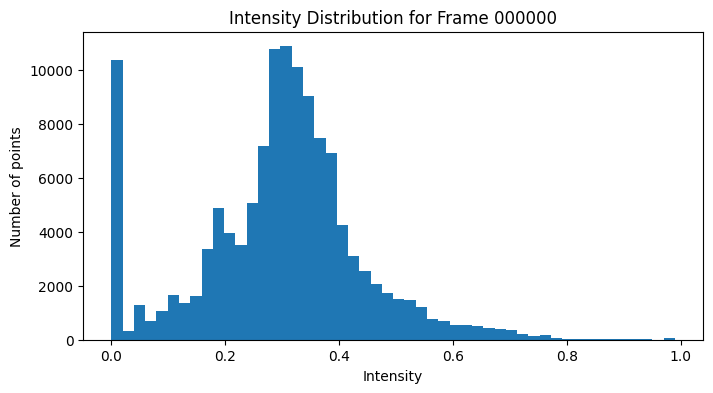

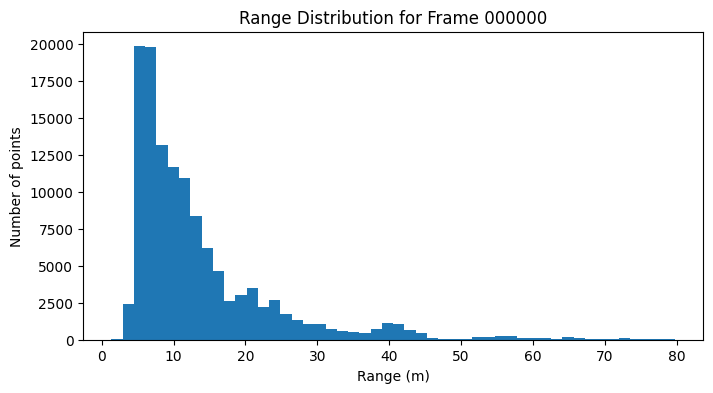

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(intensity, bins=50)
plt.xlabel("Intensity")
plt.ylabel("Number of points")
plt.title("Intensity Distribution for Frame 000000")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(ranges, bins=50)
plt.xlabel("Range (m)")
plt.ylabel("Number of points")
plt.title("Range Distribution for Frame 000000")
plt.show()

**The histograms show plausible intensity and range distributions, with most points concentrated at moderate intensities and shorter sensor distances.**

## Step 10: Create a bird’s-eye view of the point cloud

In this step, we make a simple top-down scatter plot using the `x` and `y` coordinates, colored by intensity.

This gives a visual sanity check of the spatial structure of the frame and helps confirm that the point cloud resembles a real driving scene.

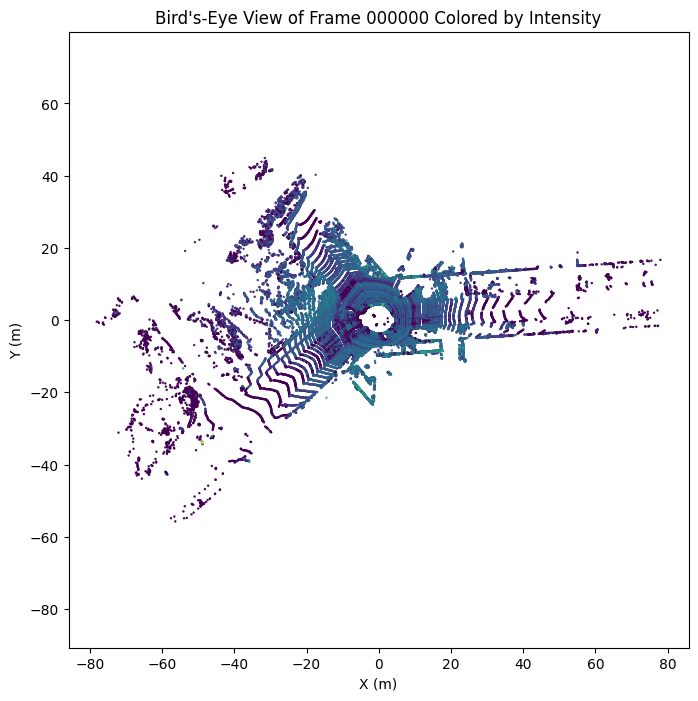

In [12]:
plt.figure(figsize=(8, 8))
plt.scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=intensity,
    s=0.5
)
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Bird's-Eye View of Frame 000000 Colored by Intensity")
plt.axis("equal")
plt.show()

**The bird’s-eye view shows a realistic LiDAR scan pattern and confirms that the frame geometry has been loaded correctly.**

## Step 11: Visualize the semantic composition of the frame

In this step, we create a bar chart of the semantic class IDs present in the selected frame and their corresponding point counts.

This gives a compact visual summary of the frame’s label distribution.

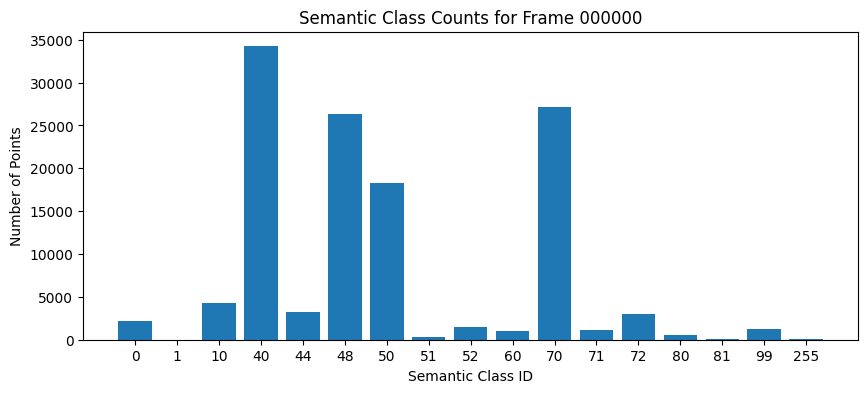

In [13]:
plt.figure(figsize=(10, 4))
plt.bar(unique_semantic.astype(str), semantic_counts)
plt.xlabel("Semantic Class ID")
plt.ylabel("Number of Points")
plt.title("Semantic Class Counts for Frame 000000")
plt.show()

**The class-count plot confirms that the selected frame has a structured and nontrivial semantic label distribution.**

## Summary of Notebook 01

**In this notebook, we successfully loaded a SemanticKITTI sequence, verified the dataset structure, loaded the first LiDAR frame and its matching labels, confirmed point-label alignment, unpacked semantic and instance labels, and produced basic statistical and visual sanity checks.**

**These results confirm that the data-loading pipeline is working correctly and that the project is ready to move to the next notebook.**

---